<a href="https://colab.research.google.com/github/GFDRR/urban_validation/blob/main/02_builtup_accuracy_rasters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/'Gates Foundation'/'Building Dataset Validation'/data/03_processed

# Global Built-Up / Building Surface Validation — Raster Workflow

This notebook implements a tile-based validation pipeline for city-scale **raster** built-up products (e.g., WSF/WSF-Tracker, TEMPO, GHS Built-Up). It compares global built-up layers against a high-quality **reference building footprint dataset** by rasterizing the reference onto each candidate raster grid and computing per-tile and city-level accuracy metrics.

The workflow follows a modular structure:

1) **Set-up and configurations**  
   * Load YAML configuration (AOI, CRS, tile size, raster candidates, thresholds)  
   * Define dataset-specific adapters (e.g., fraction, percent, m²/pixel, categorical codes)

2) **AOI tiling**  
   * Divide the city AOI into fixed-size tiles (e.g., 1 km × 1 km) to enable scalable processing  
   * Create per-tile evaluation windows on each raster grid

3) **Reference rasterization (vector → raster)**  
   * For each tile and raster candidate, rasterize reference building polygons onto the candidate raster grid  
   * Compute **fractional building coverage per pixel** via oversampling to handle sub-pixel buildings

4) **Candidate raster interpretation (raster → built-up area)**  
   * Convert each candidate raster into **predicted built-up area per pixel** (*A_pred*, m²/pixel) using dataset-specific logic:  
     - Fraction/density rasters (0–1): *A_pred = fraction × pixel_area*  
     - Percent rasters (0–100): *A_pred = (percent/100) × pixel_area*  
     - Built-up area rasters (m²/pixel): *A_pred = value* (optionally clamped to pixel_area)  
     - Encoded/categorical rasters: apply code rules / thresholds

5) **Computing accuracy metrics (per tile, then aggregated)**  
   * **Binary metrics** (after thresholding both reference and prediction):  
     - True Positives (TP), False Positives (FP), False Negatives (FN)  
     - Precision, Recall, F1-score  
     - Quantity disagreement and allocation disagreement  
   * **Area-based metrics** (continuous):  
     - Reference and predicted built-up area (m²)  
     - Relative area error, signed area bias, MAE / RMSE (tile-level and city-level)

6) **Visualizing outputs**  
   * Per-tile metrics tables (all datasets)  
   * City-level summaries and rankings  
   * F1 heatmaps (tiles colored by score)  
   * Diagnostics for coverage gaps (tiles with area_ref=0 but area_pred>0)

Created by: Caroline Gevaert — The World Bank  
Financed by: The Gates Foundation  
Last update: February 5, 2026

**To-do:**
- set up a GitHub repo for reproducible execution (env + data pointers + config examples)
- standardize outputs for reporting (tables/figures aligned with project templates)
- add optional “reference coverage mask” to avoid penalizing areas outside the reference cut footprint


In [ ]:
# ---- Imports ----
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio import features
from rasterio.windows import from_bounds
from rasterio.transform import Affine
from rasterio.vrt import WarpedVRT
from rasterio.warp import Resampling

import matplotlib.pyplot as plt
import seaborn as sns

import yaml

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Project root (folder)
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation"
)

# === Load config ===
CONFIG_PATH = PROJECT_ROOT / "configs/ssd-juba.yaml"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("CONFIG_PATH =", CONFIG_PATH)

with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

ROOT = (PROJECT_ROOT / cfg["root_dir"]).resolve()
CITY = cfg["city"]

CRS = cfg["crs"]
AOI_PATH = ROOT / cfg["aoi_path"]
REF_PATH = ROOT / cfg["reference_vector"]
CANDIDATES = cfg["candidates"]

MIN_AREA_M2 = cfg.get("min_area_m2", 10)
TILE_SIZE_M = cfg.get("tile_size_m", 1000)  # Default to 1km tiles

rv = cfg.get("raster_validation", {})
TAU_FRAC = float(rv.get("tau_frac", 0.2))
OVERSAMPLE = int(rv.get("oversample_factor", 4))
ALL_TOUCHED = bool(rv.get("all_touched", False))

RASTER_CANDS = cfg.get("raster_candidates", [])

# Output dirs (mirrors vector notebook)
metrics_dir = ROOT / f"outputs/metrics/{CITY.lower()}"
metrics_dir.mkdir(parents=True, exist_ok=True)

figures_dir = ROOT / f"outputs/figures/{CITY.lower()}"
figures_dir.mkdir(parents=True, exist_ok=True)

tiles_path = ROOT / f"data/02_interim/tiles/{CITY.lower()}_tiles.gpkg"

print("CITY:", CITY)
print("Root:", ROOT)
print("CRS:", CRS)
print("Tiles:", tiles_path)
print("Raster candidates:", [d['name'] for d in RASTER_CANDS])


PROJECT_ROOT = /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation
CONFIG_PATH = /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/configs/ssd-juba.yaml
CITY: ssd-juba
Root: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation
CRS: EPSG:32636
Tiles: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/data/02_interim/tiles/ssd-juba_tiles.gpkg
Raster candidates: ['wsf-tracker202507', 'tempo', 'ghs']


In [ ]:
# ---- Helpers: saving figures ----
def fig_name(stem: str, ext: str = "png") -> str:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{CITY.lower()}_{stem}_{ts}.{ext}"

def save_figure(fig, filename: str, dpi: int = 200):
    out_path = figures_dir / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {out_path}")


In [ ]:
# ---- Helpers: AOI + tiles (reuse Section III tiles if available) ----
def load_aoi(path: Path, crs: str) -> gpd.GeoDataFrame:
    aoi = gpd.read_file(path)
    if aoi.crs is None:
        raise ValueError(f"{path} has no CRS defined.")
    return aoi.to_crs(crs)

def make_tiles(aoi: gpd.GeoDataFrame, tile_size_m: float) -> gpd.GeoDataFrame:
    aoi_union = aoi.geometry.union_all()
    minx, miny, maxx, maxy = aoi_union.bounds

    xs = np.arange(minx, maxx, tile_size_m)
    ys = np.arange(miny, maxy, tile_size_m)

    polys = []
    tile_ids = []
    tid = 0
    for x in xs:
        for y in ys:
            poly = gpd.GeoSeries.from_bbox((x, y, x + tile_size_m, y + tile_size_m)).iloc[0]
            if poly.intersects(aoi_union):
                polys.append(poly.intersection(aoi_union))
                tile_ids.append(tid)
                tid += 1

    tiles = gpd.GeoDataFrame({"tile_id": tile_ids, "geometry": polys}, crs=aoi.crs)
    return tiles

# Always load AOI (needed for backup clipping mask)
aoi = load_aoi(AOI_PATH, CRS)
aoi_union = aoi.geometry.union_all()

# Load or create tiles
if tiles_path.exists():
    tiles = gpd.read_file(tiles_path)
    tiles = tiles.to_crs(CRS)
    print("Loaded tiles:", len(tiles))
else:
    aoi = load_aoi(AOI_PATH, CRS)
    tiles = make_tiles(aoi, TILE_SIZE_M)
    tiles_path.parent.mkdir(parents=True, exist_ok=True)
    tiles.to_file(tiles_path, driver="GPKG")
    print("Created tiles:", len(tiles))

tiles.head()


Loaded tiles: 404


,tile_id,geometry
0,0,"POLYGON ((324376 533064, 324376 534064, 323376..."
1,1,"POLYGON ((324376 534064, 324376 535064, 323376..."
2,2,"POLYGON ((324376 535064, 324376 536064, 323376..."
3,3,"POLYGON ((324376 536064, 324376 537064, 323376..."
4,4,"POLYGON ((324376 538064, 324376 539064, 323376..."


In [ ]:
# ---- Load reference buildings ----
def load_buildings(path: Path, crs: str, min_area_m2: float) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"{path} has no CRS defined.")

    # Reproject to the working CRS for spatial ops
    gdf = gdf.to_crs(crs)

    # Compute area in meters using a local UTM (robust even if crs is EPSG:4326)
    try:
        metric_crs = gdf.estimate_utm_crs()  # geopandas helper
        gdf_metric = gdf.to_crs(metric_crs)
        gdf["area_m2"] = gdf_metric.geometry.area
    except Exception as e:
        raise ValueError(
            f"Failed to compute area in meters. "
            f"Check CRS and geometry validity. Underlying error: {e}"
        )

    # Apply the min-area filter in true m²
    gdf = gdf[gdf["area_m2"] >= float(min_area_m2)].copy()
    gdf.reset_index(drop=True, inplace=True)
    return gdf


ref = load_buildings(REF_PATH, CRS, MIN_AREA_M2)

# Clip reference to AOI to guarantee overlap with tiles
ref = gpd.clip(ref, aoi_union)
ref = ref[~ref.is_empty].copy()
ref.reset_index(drop=True, inplace=True)

print("Reference buildings after AOI clip:", len(ref))

# # Fix invalid/empty geometries (only if needed)
# if (~ref.is_valid).any():
#     ref = ref.copy()
#     ref["geometry"] = ref.geometry.buffer(0)  # quick make-valid for many issues

# ref = ref[~ref.is_empty].copy()
# ref_sindex = ref.sindex

# Safer geometry fix (requires shapely>=2)
ref = ref.copy()
ref["geometry"] = ref.geometry.make_valid()
ref = ref[ref.is_valid & ~ref.is_empty].copy()
ref_sindex = ref.sindex

print("Reference buildings:", len(ref))
print("Invalid geometries after fix:", int((~ref.is_valid).sum()))
print("Empty geometries after fix:", int(ref.is_empty.sum()))
ref.head()


Reference buildings after AOI clip: 185631
Reference buildings: 185631
Invalid geometries after fix: 0
Empty geometries after fix: 0


,full_id,osm_id,osm_type,building,name,amenity,brand,wheelchair,geometry,area_m2
0,w1348062167,1348062167,way,yes,None,None,None,None,"POLYGON ((348208.645 525376.677, 348209.406 52...",118.690371
1,w1361917478,1361917478,way,yes,None,None,None,None,"POLYGON ((348186.392 525381.664, 348187.894 52...",20.107920
2,w1361917476,1361917476,way,yes,None,None,None,None,"POLYGON ((348198.919 525388.87, 348200.421 525...",20.070262
3,w1361917494,1361917494,way,yes,None,None,None,None,"POLYGON ((348349.151 525525.69, 348350.342 525...",30.988973
4,w1361922818,1361922818,way,yes,None,None,None,None,"POLYGON ((348366.394 526038.455, 348367.525 52...",62.152614


In [ ]:
print("CRS in config:", CRS)
print("ref.crs:", ref.crs)
print("tiles.crs:", tiles.crs)
print("AOI bounds:", aoi_union.bounds)

# If ref is empty, stop early with a useful error
if len(ref) == 0:
    raise ValueError(
        "Reference GeoDataFrame is empty AFTER filtering. "
        "This is usually because CRS is geographic (degrees) and you computed area in degrees², "
        "then applied min_area_m2 in m²."
    )

# Check overlap quickly
print("ref bounds:", ref.total_bounds)
print("tiles bounds:", tiles.total_bounds)

# Quick overlap test
tiles_union = tiles.geometry.union_all()
n_intersect = int(ref.intersects(tiles_union).sum())
print("Reference buildings intersecting tiles:", n_intersect, "/", len(ref))


CRS in config: EPSG:32636
ref.crs: EPSG:32636
tiles.crs: EPSG:32636
AOI bounds: (323376.86507716303, 524064.19746062404, 353416.2550837875, 544767.3767396447)
ref bounds: [323537.55144696 524861.17259082 353326.30152443 544489.38616115]
tiles bounds: [323376. 524064. 354376. 545064.]
Reference buildings intersecting tiles: 185631 / 185631


In [ ]:
# ---- Helpers: open raster in target CRS + AOI mask ----
def choose_resampling(binarize_spec: dict) -> Resampling:
    method = binarize_spec.get("method", "threshold")
    # Keep categorical rasters crisp
    if method in {"wsf_tracker", "value_in", "nonzero", "binary"}:
        return Resampling.nearest
    # Continuous rasters (fraction/percent/area) can use bilinear if reprojection is needed
    return Resampling.bilinear

def open_in_target_crs(src: rasterio.io.DatasetReader, target_crs: str, binarize_spec: dict):
    """Return a dataset-like object in target CRS. Uses WarpedVRT when CRS differs."""
    if src.crs is None:
        raise ValueError("Raster has no CRS.")
    if str(src.crs) == str(target_crs):
        return src  # already aligned
    resampling = choose_resampling(binarize_spec)
    return WarpedVRT(src, crs=target_crs, resampling=resampling)

def aoi_mask_for_window(aoi_geom, out_shape, transform, all_touched: bool = False) -> np.ndarray:
    """Rasterize AOI geometry to a boolean mask on the given window grid."""
    mask = features.rasterize(
        [(aoi_geom, 1)],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype="uint8",
        all_touched=all_touched,
    )
    return mask.astype(bool)


In [ ]:
# ---- Raster adapters: convert each raster into predicted built-up area per pixel (m²) ----
def _pixel_area_from_transform(transform) -> float:
    # Assumes north-up (no rotation). For rotated rasters, you'd compute polygon area, but we keep it simple here.
    return float(abs(transform.a * transform.e))

def predicted_area_from_raster(arr: np.ndarray, transform, spec: dict) -> np.ndarray:
    """Convert raster values into predicted built-up area per pixel (m²), on the raster grid.

    Supported `spec["method"]` values:
      - "wsf_tracker": categorical 0..K time bins (0=non-built, 1..K built-by-time), built if 1..as_of_code
      - "percent": values in [0..100] represent percent built-up
      - "fraction": values in [0..1] represent built-up fraction (TEMPO band 1 fits here)
      - "area_m2": values already represent built-up area in m² per pixel (e.g., GHS built-up)
      - "binary": built if value >= threshold (default 1)
      - "nonzero": built if value != 0
      - "value_in": built if value is in a set
      - "threshold": legacy mode (scale/offset + threshold). Area uses the scaled score as fraction (clipped 0..1).
    """
    method = spec.get("method", "threshold")
    pixel_area = _pixel_area_from_transform(transform)

    arr_f = arr.astype("float32")

    if method == "wsf_tracker":
        as_of_code = int(spec.get("as_of_code", 19))
        built_min = int(spec.get("built_value_min", 1))
        nonbuilt = int(spec.get("nonbuilt_value", 0))
        built = (arr != nonbuilt) & (arr >= built_min) & (arr <= as_of_code)
        return built.astype("float32") * pixel_area

    if method == "percent":
        clamp_min = float(spec.get("clamp_min", 0.0))
        clamp_max = float(spec.get("clamp_max", 100.0))
        v = np.clip(arr_f, clamp_min, clamp_max)
        frac = np.clip(v / 100.0, 0.0, 1.0)
        return frac * pixel_area

    if method == "fraction":
        clamp_min = float(spec.get("clamp_min", 0.0))
        clamp_max = float(spec.get("clamp_max", 1.0))
        frac = np.clip(arr_f, clamp_min, clamp_max)
        return frac * pixel_area

    if method == "area_m2":
        # Values already represent built-up area in m² per pixel.
        A = np.maximum(arr_f, 0.0)
        if bool(spec.get("clamp_to_pixel_area", True)):
            A = np.minimum(A, pixel_area)
        return A

    if method == "binary":
        thr = float(spec.get("threshold", 1.0))
        built = arr_f >= thr
        return built.astype("float32") * pixel_area

    if method == "nonzero":
        built = arr_f != 0
        return built.astype("float32") * pixel_area

    if method == "value_in":
        values = set(spec.get("values", []))
        built = np.isin(arr, list(values))
        return built.astype("float32") * pixel_area

    if method == "threshold":
        scale = float(spec.get("scale", 1.0))
        offset = float(spec.get("offset", 0.0))
        score = arr_f * scale + offset
        # Interpret score as a fraction-like quantity for area (clip to [0,1])
        frac = np.clip(score, 0.0, 1.0)
        return frac * pixel_area

    raise ValueError(f"Unknown raster method: {method}")

def pred_bin_from_pred_area(A_pred: np.ndarray, transform, spec: dict) -> np.ndarray:
    """Derive a binary built/unbuilt map from predicted built-up area (m²)."""
    pixel_area = _pixel_area_from_transform(transform)
    # Preferred: threshold on predicted fraction
    tau_pred_frac = spec.get("threshold_frac", None)
    if tau_pred_frac is None:
        # Sensible defaults: categorical/binary rasters -> built if any built area
        if spec.get("method", "threshold") in {"wsf_tracker", "binary", "nonzero", "value_in"}:
            return A_pred > 0
        # otherwise align with TAU_FRAC (reference fraction threshold)
        return (A_pred / pixel_area) >= TAU_FRAC
    return (A_pred / pixel_area) >= float(tau_pred_frac)

# (Optional) keep legacy function for backwards compatibility / debugging
def binarize_raster(arr: np.ndarray, spec: dict) -> tuple[np.ndarray, np.ndarray]:
    """Legacy helper: returns (pred_score, pred_bin)."""
    method = spec.get("method", "threshold")
    score = arr.astype("float32")

    if method == "threshold":
        scale = float(spec.get("scale", 1.0))
        offset = float(spec.get("offset", 0.0))
        thr = float(spec.get("threshold", 0.5))
        score = score * scale + offset
        pred_bin = score >= thr
        return score, pred_bin

    if method == "nonzero":
        pred_bin = score != 0
        score = pred_bin.astype("float32")
        return score, pred_bin

    if method == "value_in":
        values = set(spec.get("values", []))
        pred_bin = np.isin(arr, list(values))
        score = pred_bin.astype("float32")
        return score, pred_bin

    if method == "wsf_tracker":
        as_of_code = int(spec.get("as_of_code", 19))
        built_min = int(spec.get("built_value_min", 1))
        nonbuilt = int(spec.get("nonbuilt_value", 0))
        pred_bin = (arr != nonbuilt) & (arr >= built_min) & (arr <= as_of_code)
        score = pred_bin.astype("float32")
        return score, pred_bin

    raise ValueError(f"Unknown binarize method: {method}")


In [ ]:
# ---- Reference rasterization onto candidate grid (fractional coverage via oversampling) ----
def rasterize_ref_fraction(ref_geoms, out_shape, transform, oversample=4, all_touched=False) -> np.ndarray:
    '''
    Approximate fractional polygon coverage per pixel by rasterizing at higher resolution (oversample factor)
    and averaging subpixels.
    '''
    if len(ref_geoms) == 0:
        return np.zeros(out_shape, dtype="float32")

    if oversample <= 1:
        mask = features.rasterize(
            [(geom, 1) for geom in ref_geoms],
            out_shape=out_shape,
            transform=transform,
            fill=0,
            dtype="uint8",
            all_touched=all_touched
        )
        return mask.astype("float32")

    h, w = out_shape
    oh, ow = h * oversample, w * oversample
    hi_transform = transform * Affine.scale(1.0 / oversample, 1.0 / oversample)

    hi = features.rasterize(
        [(geom, 1) for geom in ref_geoms],
        out_shape=(oh, ow),
        transform=hi_transform,
        fill=0,
        dtype="uint8",
        all_touched=all_touched
    ).astype("float32")

    # Downsample by block-mean
    hi = hi.reshape(h, oversample, w, oversample).mean(axis=(1, 3))
    return hi.astype("float32")


In [ ]:
import numpy as np
from rasterio.windows import Window
from rasterio.windows import intersection as win_intersection

def read_window_padded(src, band, window, out_shape, fill_value):
    """
    Read window from src WITHOUT boundless reads.
    If window goes out of bounds, returns an array of out_shape filled with fill_value,
    with the in-bounds data pasted into the correct location.
    """
    # The valid window for the dataset
    full = Window(0, 0, src.width, src.height)

    try:
        w_int = win_intersection(window, full)
    except Exception:
        # No overlap at all
        return np.full(out_shape, fill_value, dtype="float32")

    # Prepare padded output
    out = np.full(out_shape, fill_value, dtype="float32")

    # Read only the intersecting part (NO boundless!)
    data = src.read(band, window=w_int, boundless=False).astype("float32")

    # Compute where to paste into out
    row_off = int(round(w_int.row_off - window.row_off))
    col_off = int(round(w_int.col_off - window.col_off))

    h, w = data.shape
    out[row_off:row_off + h, col_off:col_off + w] = data
    return out


In [ ]:
# ---- Per-tile evaluation for one raster dataset ----
def eval_raster_dataset_for_tiles(raster_path: Path, cand: dict) -> pd.DataFrame:
    """Evaluate one raster dataset over all tiles.

    Core idea:
      - Build reference built-up fraction per pixel (f_ref) by rasterizing reference polygons onto the raster grid.
      - Convert candidate raster to *predicted built-up area per pixel* (A_pred, m²) using dataset-specific adapter.
      - Compare:
          * area-based metrics (works for binary, density, fraction, m² rasters)
          * optional binary metrics (TP/FP/FN/F1) using fraction thresholds.
    """
    bin_spec = cand.get("binarize", {"method": "threshold", "threshold": 0.5})
    rast_over = cand.get("rasterization", {}) or {}
    oversample = int(rast_over.get("oversample_factor", OVERSAMPLE))
    all_touched = bool(rast_over.get("all_touched", ALL_TOUCHED))
    band = int(bin_spec.get("band", 1))

    rows = []
    with rasterio.open(raster_path) as src:
        ds = open_in_target_crs(src, CRS, bin_spec)

        if ds.crs is None:
            raise ValueError(f"{raster_path} has no CRS.")

        # nodata handling: allow YAML to override (including forcing None)
        if "nodata" in bin_spec:
            nodata = bin_spec.get("nodata", None)
        else:
            nodata = ds.nodata

        for _, tile in tiles.iterrows():
            tile_id = int(tile["tile_id"])
            geom = tile.geometry
            minx, miny, maxx, maxy = geom.bounds

            win = from_bounds(minx, miny, maxx, maxy, transform=ds.transform)
            if win.width <= 0 or win.height <= 0:
                continue

            # Desired output array shape for this window (height, width)
            out_shape = (int(round(win.height)), int(round(win.width)))

            #arr = ds.read(band, window=win, boundless=True, fill_value=nodata)
            fill = nodata if nodata is not None else 0.0  # safe default
            arr = read_window_padded(ds, band, win, out_shape, fill_value=fill)

            # Use the window-specific transform (important!)
            transform = rasterio.windows.transform(win, ds.transform)

            # Calculate pixel area
            pixel_area = _pixel_area_from_transform(transform)  # m² per pixel (dataset-specific)

            # Valid pixels mask = AOI (and optionally nodata mask)
            aoi_mask = aoi_mask_for_window(aoi_union, arr.shape, transform, all_touched=all_touched)
            valid = aoi_mask.copy()
            if nodata is not None:
                # Avoid accidentally masking valid zeros for continuous rasters (common pitfall)
                if not (nodata in (0, 255) and bin_spec.get("method") in {"fraction", "percent", "area_m2"}):
                    valid &= (arr != nodata)

            n_valid = int(valid.sum())
            if n_valid == 0:
                # no evaluation area in this tile
                rows.append({
                    "tile_id": tile_id,
                    "tp": 0, "fp": 0, "fn": 0,
                    "precision": 0.0, "recall": 0.0, "f1": 0.0,
                    "quantity_disagreement": 0.0, "allocation_disagreement": 0.0,
                    "n_valid_pixels": 0,
                    "pixel_area_m2": float(pixel_area),
                    "valid_area_m2": 0.0,
                    "area_ref_m2": 0.0,
                    "area_pred_m2": 0.0,
                    "rel_area_error": np.nan,
                    "signed_area_bias_m2": 0.0,
                    "mae_area_m2": 0.0,
                    "rmse_area_m2": 0.0
                })
                continue

            # --- Prediction: A_pred in m²/pixel + binary pred_bin ---
            A_pred = predicted_area_from_raster(arr, transform, bin_spec)
            pred_bin = pred_bin_from_pred_area(A_pred, transform, bin_spec)

            # --- Reference subset (vector) for this tile ---
            possible = list(ref_sindex.intersection(geom.bounds))
            ref_tile = ref.iloc[possible]
            ref_tile = ref_tile[ref_tile.intersects(geom)]
            ref_geoms = list(ref_tile.geometry)

            # Rasterize reference footprints to fraction per pixel on the candidate grid
            f_ref = rasterize_ref_fraction(ref_geoms, arr.shape, transform, oversample=oversample, all_touched=all_touched)
            pixel_area = _pixel_area_from_transform(transform)
            A_ref = f_ref * pixel_area
            ref_bin = (A_ref / pixel_area) >= TAU_FRAC

            # --- Confusion counts on valid pixels ---
            p = pred_bin[valid]
            r = ref_bin[valid]
            tp = int(np.logical_and(p, r).sum())
            fp = int(np.logical_and(p, ~r).sum())
            fn = int(np.logical_and(~p, r).sum())

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

            # --- Area-based metrics on valid pixels ---
            area_ref = float(A_ref[valid].sum())
            area_pred = float(A_pred[valid].sum())

            rel_area_error = (abs(area_pred - area_ref) / area_ref) if area_ref > 0 else np.nan
            signed_area_bias = area_pred - area_ref
            mae_area = abs(signed_area_bias)
            rmse_area = abs(signed_area_bias)

            # Disagreement decomposition (binary; following Pontius-like decomposition)
            # Quantity disagreement: difference in number of predicted vs reference built pixels
            n_pred = int(p.sum())
            n_ref = int(r.sum())
            qd = abs(n_pred - n_ref) / n_valid
            # Allocation disagreement: remaining disagreement after quantity
            ad = (2 * min(fp, fn)) / n_valid

            rows.append({
                "tile_id": tile_id,
                "tp": tp, "fp": fp, "fn": fn,
                "precision": precision, "recall": recall, "f1": f1,
                "quantity_disagreement": float(qd),
                "allocation_disagreement": float(ad),
                "n_valid_pixels": n_valid,
                "pixel_area_m2": float(pixel_area),
                "valid_area_m2": float(n_valid) * float(pixel_area),
                "area_ref_m2": area_ref,
                "area_pred_m2": area_pred,
                "rel_area_error": rel_area_error,
                "signed_area_bias_m2": signed_area_bias,
                "mae_area_m2": mae_area,
                "rmse_area_m2": rmse_area
            })

    return pd.DataFrame(rows)


In [ ]:
# ---- Run all raster datasets ----
all_tiles_metrics = []

for d in RASTER_CANDS:
    name = d["name"]
    path = ROOT / d["path"]
    spec = d.get("binarize", {"method": "threshold", "threshold": 0.5})

    print("\n=== Dataset:", name, "===")
    if not path.exists():
        print("WARNING: missing:", path)
        continue

    df = eval_raster_dataset_for_tiles(path, d)
    df["dataset"] = name
    all_tiles_metrics.append(df)

metrics_tiles = pd.concat(all_tiles_metrics, ignore_index=True) if all_tiles_metrics else pd.DataFrame()
out_tiles = metrics_dir / "raster_metrics_tiles_all_datasets.parquet"
metrics_tiles.to_parquet(out_tiles, index=False)
print("Wrote:", out_tiles)
metrics_tiles.head() # Note, sometimes the first blocks around the edges don't have reference data, so can result in tp/fn=0 and appear to be errors.



=== Dataset: wsf-tracker202507 ===

=== Dataset: tempo ===

=== Dataset: ghs ===
Wrote: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/raster_metrics_tiles_all_datasets.parquet


,tile_id,tp,fp,fn,precision,recall,f1,quantity_disagreement,allocation_disagreement,n_valid_pixels,pixel_area_m2,valid_area_m2,area_ref_m2,area_pred_m2,rel_area_error,signed_area_bias_m2,mae_area_m2,rmse_area_m2,dataset
0,0,0,68,0,0.0,0.0,0.0,0.021411,0.0,3176,99.077418,314669.879247,0.0,6737.264160,NaN,6737.264160,6737.264160,6737.264160,wsf-tracker202507
1,1,0,2,0,0.0,0.0,0.0,0.000313,0.0,6384,99.077418,632510.235867,0.0,198.154831,NaN,198.154831,198.154831,198.154831,wsf-tracker202507
2,2,0,82,0,0.0,0.0,0.0,0.011905,0.0,6888,99.077418,682445.254488,0.0,8124.348145,NaN,8124.348145,8124.348145,8124.348145,wsf-tracker202507
3,3,0,47,0,0.0,0.0,0.0,0.011323,0.0,4151,99.077418,411270.361699,0.0,4656.638672,NaN,4656.638672,4656.638672,4656.638672,wsf-tracker202507
4,4,0,0,0,0.0,0.0,0.0,0.000000,0.0,705,99.077418,69849.579619,0.0,0.000000,NaN,0.000000,0.000000,0.000000,wsf-tracker202507


Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Tile-level F1 over AOI — ghs_20260205_040042.png


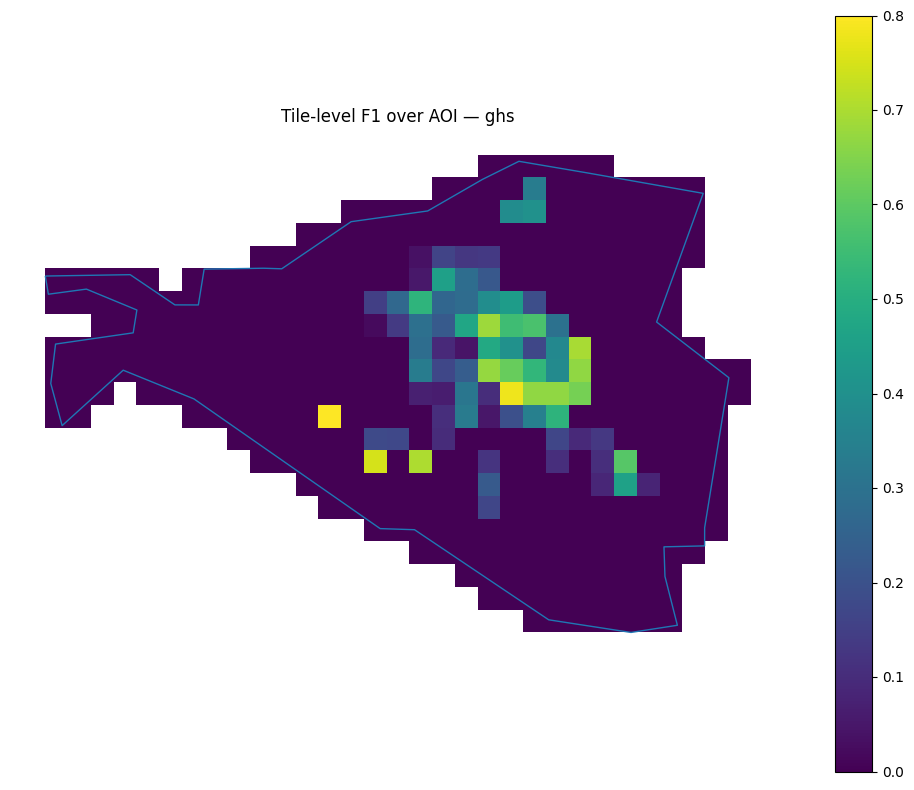

Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Tile-level F1 over AOI — tempo_20260205_040043.png


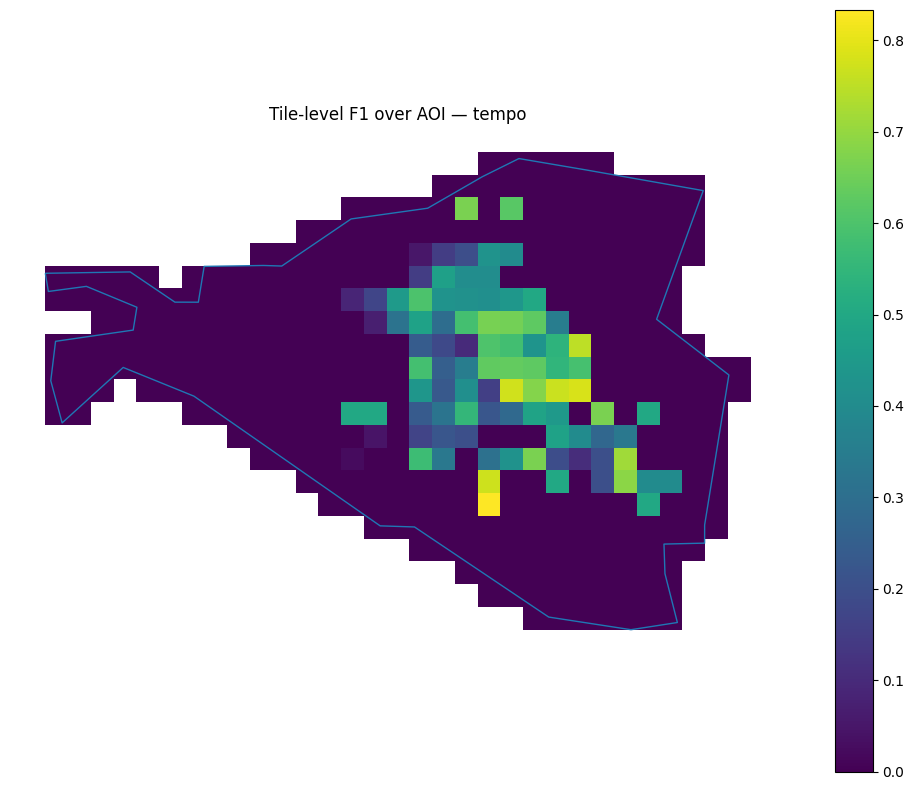

Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Tile-level F1 over AOI — wsf-tracker202507_20260205_040043.png


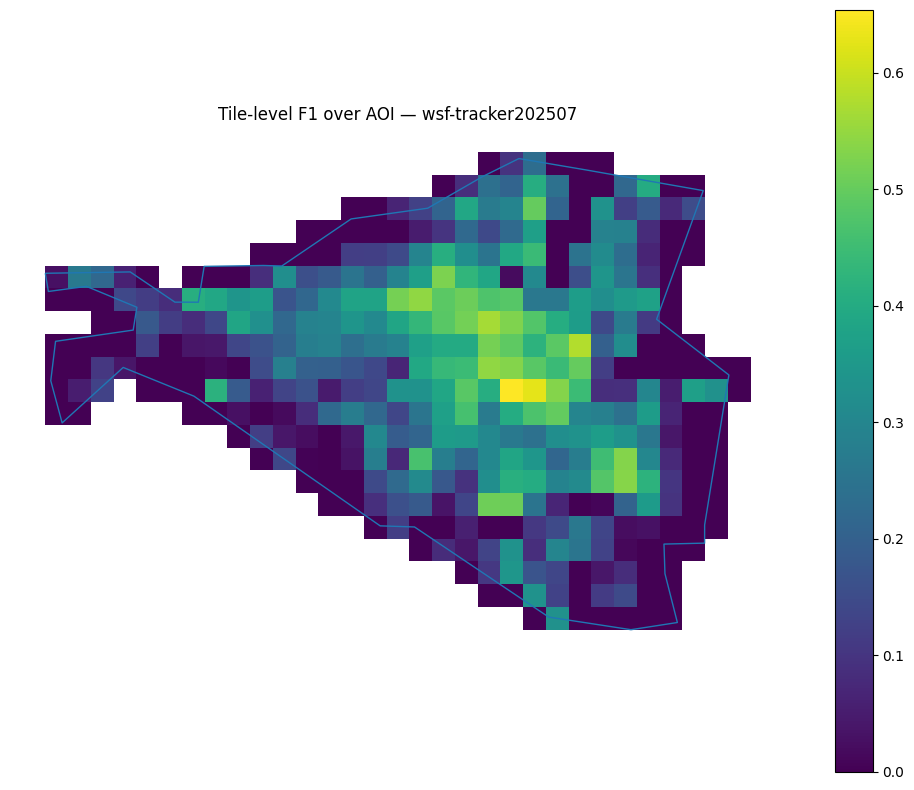

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ---- Plot: Tile-level F1 over AOI for ALL datasets ----

# Ensure join key type matches tiles
tiles_plot = tiles.copy()
tiles_plot["tile_id"] = tiles_plot["tile_id"].astype(int)

# Datasets present in the table (sorted for stable output order)
datasets = sorted(metrics_tiles["dataset"].dropna().unique().tolist())

for ds in datasets:
    m = metrics_tiles.query("dataset == @ds").copy()
    m["tile_id"] = m["tile_id"].astype(int)

    # Join metrics onto tiles geometry
    g = tiles_plot.merge(m, on="tile_id", how="left")

    # Keep only tiles that overlap the AOI (optional but recommended)
    g = g[g.intersects(aoi_union)].copy()

    # Ensure numeric + cap into [0,1]
    g["f1"] = pd.to_numeric(g["f1"], errors="coerce").clip(0, 1)

    fig, ax = plt.subplots(figsize=(10, 8))

    # AOI outline
    gpd.GeoSeries([aoi_union], crs=g.crs).boundary.plot(ax=ax, linewidth=1)

    # Choropleth by F1
    g.plot(
        ax=ax,
        column="f1",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "no metrics"},
        edgecolor="none"
    )

    ax.set_title(f"Tile-level F1 over AOI — {ds}")
    ax.set_axis_off()
    plt.tight_layout()

    save_figure(fig, fig_name(f"Tile-level F1 over AOI — {ds}"))
    plt.show()


[ghs] FP-only tiles count: 36
     tile_id  tp  fp  fn  area_ref_m2  area_pred_m2   f1
8          8   0   0   0          0.0       21457.0  0.0
385      385   0   0   0          0.0       11990.0  0.0
381      381   0   0   0          0.0        8171.0  0.0
386      386   0   0   0          0.0        6907.0  0.0
383      383   0   0   0          0.0        6674.0  0.0
6          6   0   0   0          0.0        5989.0  0.0
382      382   0   0   0          0.0        5858.0  0.0
9          9   0   0   0          0.0        5684.0  0.0
0          0   0   0   0          0.0        4226.0  0.0
283      283   0   0   0          0.0        3395.0  0.0
Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_FP-only tiles (pred built-up, no reference built-up) — ghs_20260205_040044.png


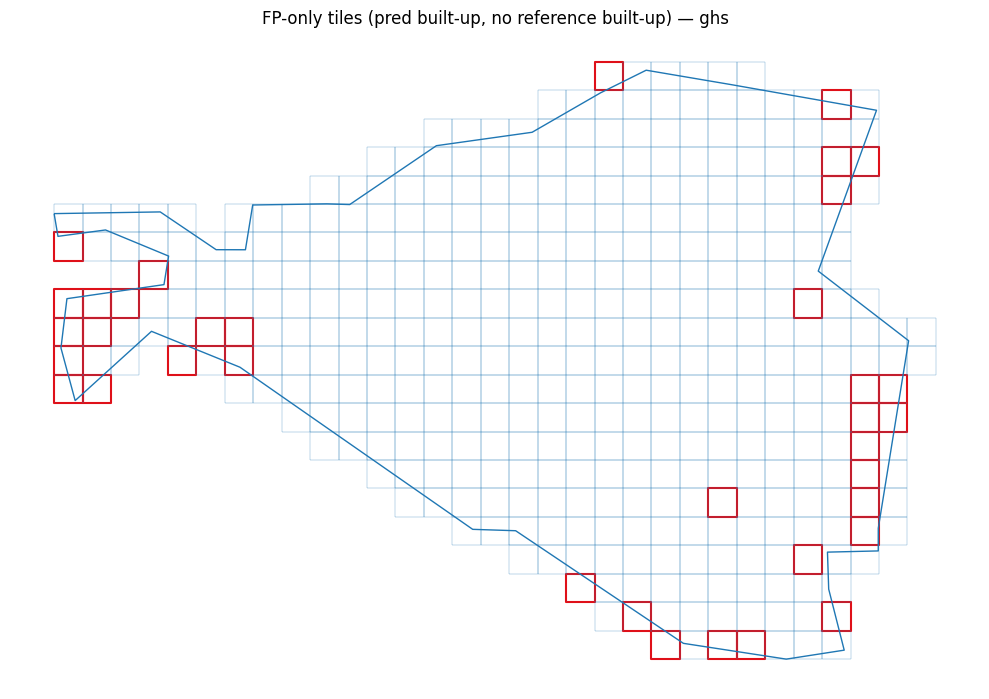

[tempo] FP-only tiles count: 46
     tile_id  tp  fp  fn  area_ref_m2  area_pred_m2   f1
283      283   0   0   0          0.0  27044.132812  0.0
383      383   0   1   0          0.0  15040.436523  0.0
385      385   0   0   0          0.0  10452.871094  0.0
384      384   0   0   0          0.0   8245.640625  0.0
371      371   0   0   0          0.0   7530.772949  0.0
343      343   0   0   0          0.0   6023.272949  0.0
8          8   0   0   0          0.0   4552.690430  0.0
9          9   0   0   0          0.0   3850.028320  0.0
340      340   0   0   0          0.0   2819.835449  0.0
381      381   0   0   0          0.0   2199.537109  0.0
Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_FP-only tiles (pred built-up, no reference built-up) — tempo_20260205_040045.png


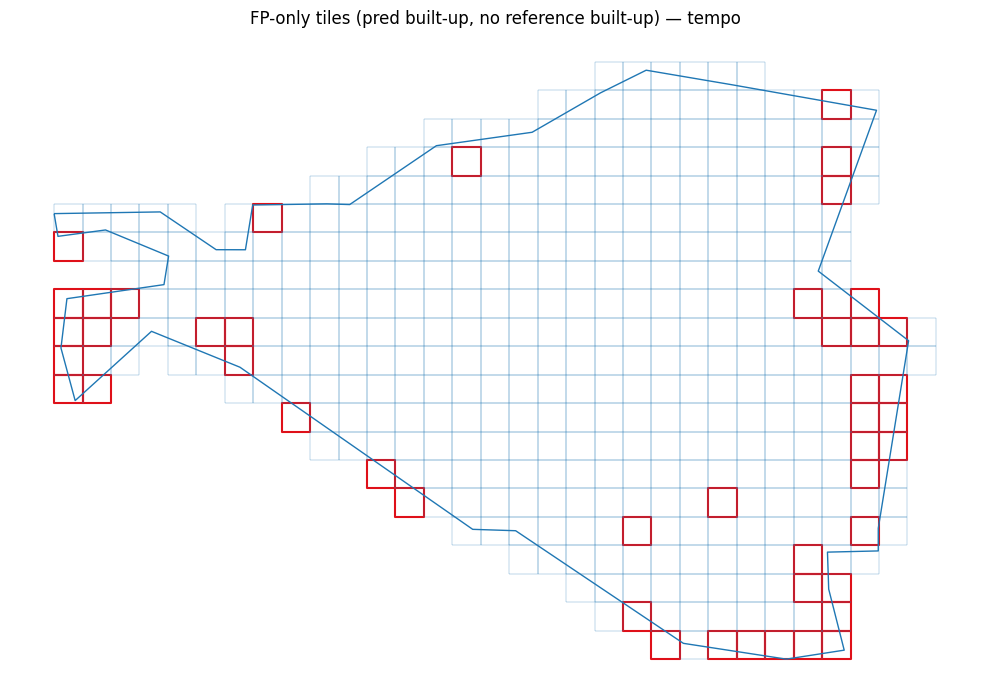

[wsf-tracker202507] FP-only tiles count: 40
     tile_id  tp    fp  fn  area_ref_m2   area_pred_m2   f1
283      283   0  1253   0          0.0  124144.000000  0.0
383      383   0   764   0          0.0   75695.148438  0.0
385      385   0   584   0          0.0   57861.210938  0.0
371      371   0   549   0          0.0   54393.500000  0.0
384      384   0   413   0          0.0   40918.972656  0.0
8          8   0   233   0          0.0   23085.037109  0.0
343      343   0   203   0          0.0   20112.714844  0.0
381      381   0   180   0          0.0   17833.933594  0.0
9          9   0   131   0          0.0   12979.140625  0.0
47        47   0   115   0          0.0   11393.903320  0.0
Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_FP-only tiles (pred built-up, no reference built-up) — wsf-tracker202507_20260205_040045.png


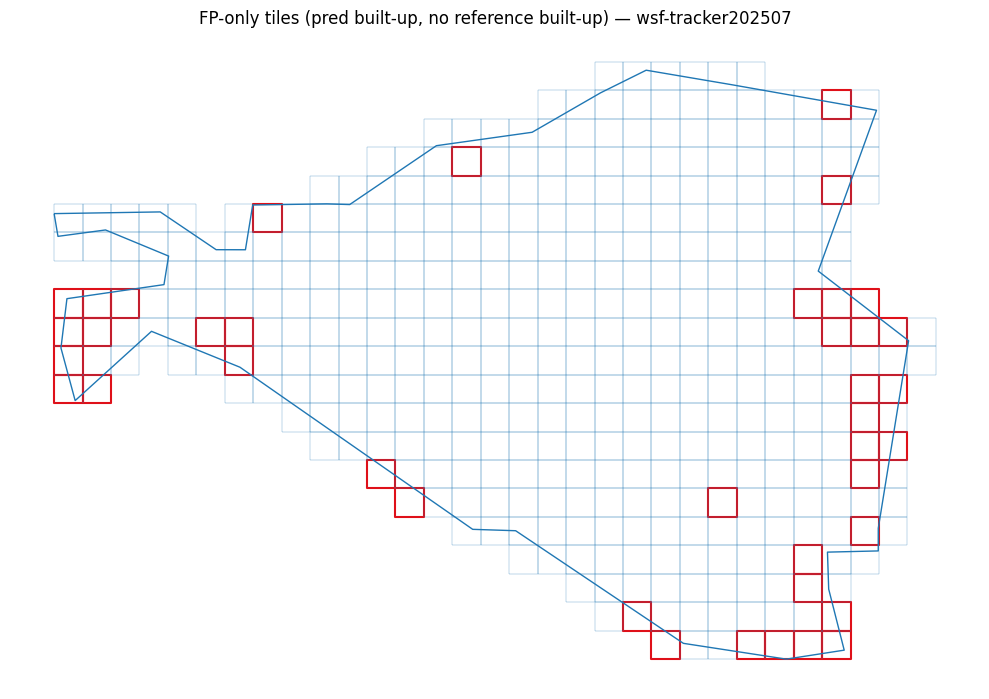

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ---- Plot: FP-only tiles (predicted built-up, no reference built-up) for ALL datasets ----

tiles_plot = tiles.copy()
tiles_plot["tile_id"] = tiles_plot["tile_id"].astype(int)

datasets = sorted(metrics_tiles["dataset"].dropna().unique().tolist())

for ds in datasets:
    m = metrics_tiles.query("dataset == @ds").copy()
    m["tile_id"] = m["tile_id"].astype(int)

    # Join metrics onto tiles geometry
    g = tiles_plot.merge(m, on="tile_id", how="left")
    g = g[g.intersects(aoi_union)].copy()

    # Pred-only / FP-only tiles: no GT/reference area, but predicted area > 0
    fp_only = g[(g["area_ref_m2"] == 0) & (g["area_pred_m2"] > 0)].copy()

    print(f"[{ds}] FP-only tiles count:", len(fp_only))
    if len(fp_only) > 0:
        display_cols = ["tile_id", "tp", "fp", "fn", "area_ref_m2", "area_pred_m2", "f1"]
        print(fp_only[display_cols].sort_values("area_pred_m2", ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(10, 8))

    # AOI outline
    gpd.GeoSeries([aoi_union], crs=g.crs).boundary.plot(ax=ax, linewidth=1)

    # Base tiles outline
    g.boundary.plot(ax=ax, linewidth=0.2)

    # Overlay FP-only tiles
    if len(fp_only) > 0:
        fp_only.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5)

    ax.set_title(f"FP-only tiles (pred built-up, no reference built-up) — {ds}")
    ax.set_axis_off()
    plt.tight_layout()

    save_figure(fig, fig_name(f"FP-only tiles (pred built-up, no reference built-up) — {ds}"))
    plt.show()


In [ ]:
# ---- City-level summary reporting ----
def summarize_city(metrics_tiles: pd.DataFrame) -> pd.DataFrame:
    out_rows = []
    for ds_name, g in metrics_tiles.groupby("dataset"):

        # Raw pixel counts (not comparable across resolutions)
        tp = int(g["tp"].sum())
        fp = int(g["fp"].sum())
        fn = int(g["fn"].sum())

        # Standard precision/recall/f1 on pixel counts
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

        # --- Area-weighted TP/FP/FN in m² ---
        if "pixel_area_m2" not in g.columns or "valid_area_m2" not in g.columns:
            raise ValueError(
                f"metrics_tiles is missing pixel_area_m2/valid_area_m2 for dataset '{ds_name}'. "
                "Re-run per-tile evaluation after adding these fields."
            )

        valid_area_total_m2 = float(g["valid_area_m2"].sum())

        tp_m2 = float((g["tp"] * g["pixel_area_m2"]).sum())
        fp_m2 = float((g["fp"] * g["pixel_area_m2"]).sum())
        fn_m2 = float((g["fn"] * g["pixel_area_m2"]).sum())

        # Normalize by evaluated area (m²) -> comparable across different pixel sizes
        tp_area_rate = tp_m2 / valid_area_total_m2 if valid_area_total_m2 > 0 else np.nan
        fp_area_rate = fp_m2 / valid_area_total_m2 if valid_area_total_m2 > 0 else np.nan
        fn_area_rate = fn_m2 / valid_area_total_m2 if valid_area_total_m2 > 0 else np.nan

        precision_area = tp_m2 / (tp_m2 + fp_m2) if (tp_m2 + fp_m2) > 0 else 0.0
        recall_area    = tp_m2 / (tp_m2 + fn_m2) if (tp_m2 + fn_m2) > 0 else 0.0
        f1_area        = (2 * precision_area * recall_area / (precision_area + recall_area)) if (precision_area + recall_area) > 0 else 0.0

        # Per-tile distributions (unchanged)
        f1_series = g["f1"].dropna()
        rel_err = g["rel_area_error"].dropna()
        qd = g["quantity_disagreement"].dropna()
        ad = g["allocation_disagreement"].dropna()

        out_rows.append({
            "city": CITY,
            "dataset": ds_name,

            # # Raw (pixel-count) confusion totals -- can be misleading as rasters have different resolutions
            # "tp": tp, "fp": fp, "fn": fn,
            # "precision": prec, "recall": rec, "f1": f1,

            # Area-weighted confusion totals + rates (recommended for comparison)
            "valid_area_total_m2": valid_area_total_m2,
            "tp_m2": tp_m2,
            "fp_m2": fp_m2,
            "fn_m2": fn_m2,
            "tp_area_rate": tp_area_rate,
            "fp_area_rate": fp_area_rate,
            "fn_area_rate": fn_area_rate,
            "precision_area" : precision_area,
            "recall_area"    : recall_area,
            "f1_area"        : f1_area,

            # Existing summaries
            "tile_f1_mean": float(f1_series.mean()) if len(f1_series) else np.nan,
            "tile_f1_median": float(f1_series.median()) if len(f1_series) else np.nan,
            "tile_f1_p25": float(f1_series.quantile(0.25)) if len(f1_series) else np.nan,
            "tile_f1_p75": float(f1_series.quantile(0.75)) if len(f1_series) else np.nan,
            "rel_area_error_mean": float(rel_err.mean()) if len(rel_err) else np.nan,
            "rel_area_error_median": float(rel_err.median()) if len(rel_err) else np.nan,
            "rel_area_error_p25": float(rel_err.quantile(0.25)) if len(rel_err) else np.nan,
            "rel_area_error_p75": float(rel_err.quantile(0.75)) if len(rel_err) else np.nan,
            "quantity_disagreement_mean": float(qd.mean()) if len(qd) else np.nan,
            "allocation_disagreement_mean": float(ad.mean()) if len(ad) else np.nan,
            "signed_area_bias_total_m2": float(g["signed_area_bias_m2"].sum()),
        })

    return pd.DataFrame(out_rows)

city_summary = summarize_city(metrics_tiles)
out_city_pq = metrics_dir / "raster_city_summary_all_datasets.parquet"
out_city_csv = metrics_dir / "raster_city_summary_all_datasets.csv"
city_summary.to_parquet(out_city_pq, index=False)
city_summary.to_csv(out_city_csv, index=False)
print("Wrote:", out_city_pq)
print("Wrote:", out_city_csv)
city_summary


Wrote: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/raster_city_summary_all_datasets.parquet
Wrote: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/raster_city_summary_all_datasets.csv


,city,dataset,valid_area_total_m2,tp_m2,fp_m2,fn_m2,tp_area_rate,fp_area_rate,fn_area_rate,precision_area,...,tile_f1_median,tile_f1_p25,tile_f1_p75,rel_area_error_mean,rel_area_error_median,rel_area_error_p25,rel_area_error_p75,quantity_disagreement_mean,allocation_disagreement_mean,signed_area_bias_total_m2
0,ssd-juba,ghs,3.521947e+08,1.059755e+07,5.840928e+07,7.774265e+05,0.030090,0.165844,0.002207,0.153572,...,0.000000,0.0,0.000000,8.040651,1.581743,0.932198,3.486667,0.140154,0.003119,1.771408e+07
1,ssd-juba,tempo,3.358635e+08,1.025731e+07,2.345436e+07,1.715328e+06,0.030540,0.069833,0.005107,0.304266,...,0.000000,0.0,0.000000,7.499702,0.901433,0.377240,1.864405,0.056770,0.007060,8.766452e+06
2,ssd-juba,wsf-tracker202507,3.427076e+08,1.743495e+07,6.218337e+07,3.281741e+06,0.050874,0.181447,0.009576,0.218982,...,0.141985,0.0,0.319832,35.917429,6.948665,3.909722,13.014628,0.148009,0.016480,6.827519e+07


Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_raster_tile_f1_boxplot_20260205_040046.png


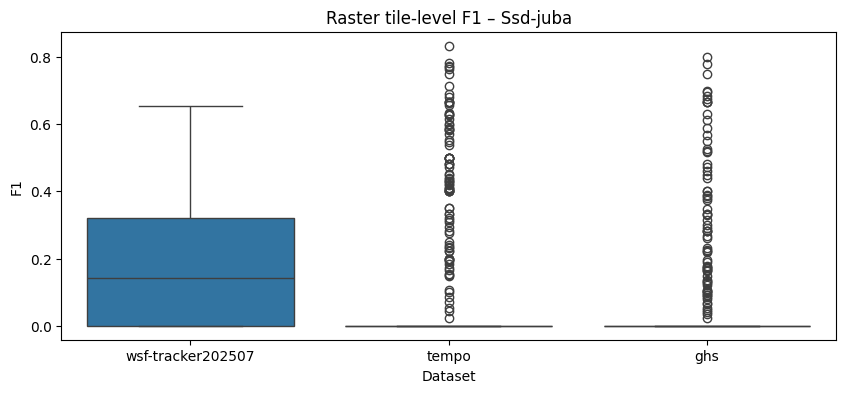

In [ ]:
# ---- Figures (saved + inline): Tile-level F1 boxplot ----
if len(metrics_tiles):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=metrics_tiles, x="dataset", y="f1", ax=ax)
    ax.set_title(f"Raster tile-level F1 – {CITY.capitalize()}")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("F1")

    save_figure(fig, fig_name("raster_tile_f1_boxplot"))
    plt.show()


Saved figure: /content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_raster_tile_rel_area_error_boxplot_20260205_040046.png


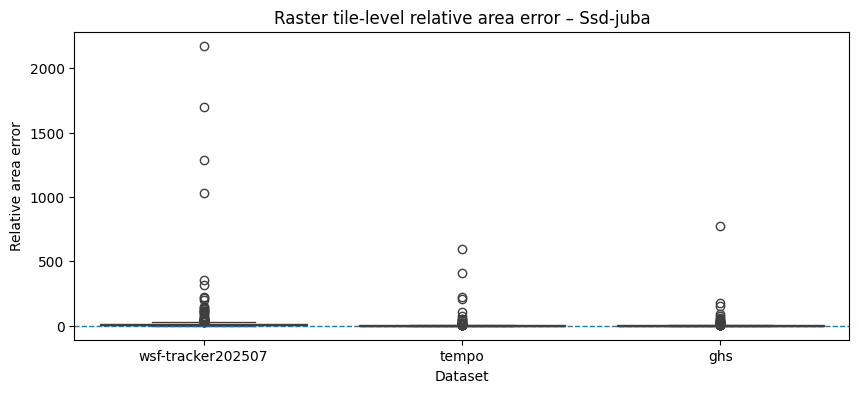

In [ ]:
# ---- Figures: relative area error distribution ----
if len(metrics_tiles):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=metrics_tiles, x="dataset", y="rel_area_error", ax=ax)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"Raster tile-level relative area error – {CITY.capitalize()}")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Relative area error")

    save_figure(fig, fig_name("raster_tile_rel_area_error_boxplot"))
    plt.show()
